In [19]:
import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader

# Find the project root by walking upward until "src" is found
current = Path.cwd()

PROJECT_ROOT = None
for path in [current] + list(current.parents):
    if (path / "src").is_dir():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find project root containing 'src'.\n"
        f"Current working directory: {current}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)

import src.evaluation.evaluator as evaluator

evaluator = importlib.reload(evaluator)
collect_predictions = evaluator.collect_predictions
evaluate_predictions = evaluator.evaluate_predictions

from src.models.biomarkers.ft_transformer import BiomarkerFTTransformer

print("Imports successful.")

Working directory: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\notebooks\04_evaluation
Project root: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service
Imports successful.


In [20]:
PROJECT_ROOT = Path("../../").resolve()

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "biomarkers"
)

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "biomarkers"
    / "biomarker_ft_transformer.pt"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "biomarkers"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [21]:
DATASETS = {
    "zheen": {
        "target_map": {
            "target": "acute_mi",
        }
    },

    "uci_heart_failure": {
        "target_map": {
            "DEATH_EVENT": "hf_mortality",
        }
    },

    "mi_complications": {
        "target_map": {
            "FIBR_PREDS": "post_mi_af",
            "PREDS_TAH": "post_mi_svt",
            "JELUD_TAH": "post_mi_vt",
            "FIBR_JELUD": "post_mi_vf",
            "A_V_BLOK": "post_mi_av_block",
            "OTEC_LANC": "post_mi_pulmonary_edema",
            "RAZRIV": "post_mi_myocardial_rupture",
            "DRESSLER": "post_mi_dressler",
            "ZSN": "post_mi_chronic_hf",
            "REC_IM": "post_mi_recurrent_mi",
            "P_IM_STEN": "post_mi_angina",
            "LET_IS": "post_mi_mortality_cause",
        }
    },

    "framingham": {
        "target_map": {
            "TenYearCHD": "ten_year_chd_risk",
        }
    },
}

MULTICLASS_TARGETS = {
    "post_mi_mortality_cause"
}

In [22]:
data = {}

for dataset_name, config in DATASETS.items():

    dataset_dir = (
        PROCESSED_DIR
        / dataset_name
    )

    X_val = np.load(
        dataset_dir / "X_val.npy"
    )

    X_test = np.load(
        dataset_dir / "X_test.npy"
    )

    y_val = pd.read_csv(
        dataset_dir / "y_val.csv"
    )

    y_test = pd.read_csv(
        dataset_dir / "y_test.csv"
    )

    y_val = y_val.rename(
        columns=config["target_map"]
    )

    y_test = y_test.rename(
        columns=config["target_map"]
    )

    data[dataset_name] = {
        "X_val": X_val.astype(
            np.float32
        ),
        "y_val": y_val,
        "X_test": X_test.astype(
            np.float32
        ),
        "y_test": y_test,
    }

    print(
        f"{dataset_name:25} "
        f"val={X_val.shape} "
        f"test={X_test.shape} "
        f"targets={list(y_test.columns)}"
    )

zheen                     val=(198, 8) test=(198, 8) targets=['acute_mi']
uci_heart_failure         val=(45, 11) test=(45, 11) targets=['hf_mortality']
mi_complications          val=(255, 113) test=(255, 113) targets=['post_mi_af', 'post_mi_svt', 'post_mi_vt', 'post_mi_vf', 'post_mi_av_block', 'post_mi_myocardial_rupture', 'post_mi_dressler', 'post_mi_chronic_hf', 'post_mi_recurrent_mi', 'post_mi_angina', 'post_mi_mortality_cause']
framingham                val=(636, 15) test=(636, 15) targets=['ten_year_chd_risk']


In [23]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
)

input_dimensions = checkpoint[
    "input_dimensions"
]

target_specs = checkpoint[
    "target_specs"
]

class_mappings = checkpoint[
    "class_mappings"
]

print("Input dimensions:")
print(input_dimensions)

print("\nTargets:")
print(target_specs.keys())

Input dimensions:
{'zheen': 8, 'uci_heart_failure': 11, 'mi_complications': 113, 'framingham': 15}

Targets:
dict_keys(['acute_mi', 'hf_mortality', 'post_mi_af', 'post_mi_svt', 'post_mi_vt', 'post_mi_vf', 'post_mi_av_block', 'post_mi_myocardial_rupture', 'post_mi_dressler', 'post_mi_chronic_hf', 'post_mi_recurrent_mi', 'post_mi_angina', 'post_mi_mortality_cause', 'ten_year_chd_risk'])


In [24]:
model_config = checkpoint["model_config"]

model = BiomarkerFTTransformer(
    input_dimensions=input_dimensions,
    target_specs=target_specs,
    d_token=model_config["d_token"],
    n_heads=model_config["n_heads"],
    n_layers=model_config["n_layers"],
    dropout=model_config["dropout"],
).to(DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Model loaded successfully.")

Model loaded successfully.


d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\src\models\biomarkers\ft_transformer.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


In [25]:
from torch.utils.data import Dataset


class BiomarkerTestDataset(Dataset):

    def __init__(
        self,
        X,
        y,
    ):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = y.reset_index(
            drop=True
        )

        self.targets = list(
            self.y.columns
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):

        x = self.X[index]

        targets = {}

        for target in self.targets:

            value = self.y.iloc[
                index
            ][target]

            if pd.isna(value):

                if target in MULTICLASS_TARGETS:
                    value = -1
                    dtype = torch.long
                else:
                    value = float("nan")
                    dtype = torch.float32

            elif target in MULTICLASS_TARGETS:

                value = int(value)
                dtype = torch.long

            else:

                value = float(value)
                dtype = torch.float32

            targets[target] = torch.tensor(
                value,
                dtype=dtype
            )

        return x, targets

In [26]:
val_loaders = {}
test_loaders = {}

for dataset_name, item in data.items():

    val_dataset = BiomarkerTestDataset(
        item["X_val"],
        item["y_val"]
    )

    test_dataset = BiomarkerTestDataset(
        item["X_test"],
        item["y_test"]
    )

    val_loaders[dataset_name] = DataLoader(
        val_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
    )

    test_loaders[dataset_name] = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
    )

    print(
        dataset_name,
        "-> val:",
        len(val_dataset),
        "test:",
        len(test_dataset),
        "samples"
    )

zheen -> val: 198 test: 198 samples
uci_heart_failure -> val: 45 test: 45 samples
mi_complications -> val: 255 test: 255 samples
framingham -> val: 636 test: 636 samples


In [27]:
validation_predictions = {}

for dataset_name, loader in val_loaders.items():

    validation_predictions[dataset_name] = collect_predictions(
        model=model,
        loader=loader,
        source=dataset_name,
        device=DEVICE,
        multiclass_targets=MULTICLASS_TARGETS,
    )

thresholds = {}

for dataset_name, predictions in validation_predictions.items():

    for target, values in predictions.items():

        if target in MULTICLASS_TARGETS:
            continue

        y_true = values["true"].astype(int)
        y_prob = values["pred"].astype(float)

        candidate_thresholds = np.unique(
            np.concatenate([
                np.array([0.0, 0.5, 1.0]),
                y_prob,
            ])
        )

        scores = [
            f1_score(
                y_true,
                (y_prob >= threshold).astype(int),
                zero_division=0,
            )
            for threshold in candidate_thresholds
        ]

        best_index = int(np.argmax(scores))
        thresholds[target] = float(
            candidate_thresholds[best_index]
        )

print("Validation-selected thresholds:")
for target, threshold in sorted(thresholds.items()):
    print(f"{target}: {threshold:.4f}")

Validation-selected thresholds:
acute_mi: 0.1986
hf_mortality: 0.2013
post_mi_af: 0.4010
post_mi_angina: 0.5730
post_mi_av_block: 0.4966
post_mi_chronic_hf: 0.5692
post_mi_dressler: 0.4356
post_mi_myocardial_rupture: 0.7270
post_mi_recurrent_mi: 0.6713
post_mi_svt: 0.6393
post_mi_vf: 0.6945
post_mi_vt: 0.8240
ten_year_chd_risk: 0.8489


In [28]:
all_predictions = {}

for dataset_name, loader in test_loaders.items():

    print(
        f"\nEvaluating {dataset_name}..."
    )

    predictions = collect_predictions(
        model=model,
        loader=loader,
        source=dataset_name,
        device=DEVICE,
        multiclass_targets=MULTICLASS_TARGETS,
    )

    all_predictions[dataset_name] = (
        predictions
    )

    print(
        f"Completed {dataset_name}"
    )


Evaluating zheen...
Completed zheen

Evaluating uci_heart_failure...
Completed uci_heart_failure

Evaluating mi_complications...
Completed mi_complications

Evaluating framingham...
Completed framingham


In [29]:
all_metrics = {}

for dataset_name, predictions in all_predictions.items():

    all_metrics[dataset_name] = (
        evaluate_predictions(
            predictions,
            multiclass_targets=MULTICLASS_TARGETS,
            thresholds=thresholds,
        )
    )

    print(
        f"Metrics calculated: "
        f"{dataset_name}"
    )

Metrics calculated: zheen
Metrics calculated: uci_heart_failure
Metrics calculated: mi_complications
Metrics calculated: framingham


In [30]:
rows = []

for dataset_name, dataset_metrics in all_metrics.items():

    for target, metrics in dataset_metrics.items():

        row = {
            "dataset": dataset_name,
            "target": target,
        }

        row.update(metrics)

        rows.append(row)

metrics_df = pd.DataFrame(
    rows
)

display(
    metrics_df.round(4)
)

,dataset,target,auroc,auprc,f1,precision,recall,accuracy,f1_macro
0,zheen,acute_mi,0.8922,0.9425,0.8327,0.7452,0.9435,NaN,NaN
1,uci_heart_failure,hf_mortality,0.6289,0.4611,0.5217,0.3871,0.8000,NaN,NaN
2,mi_complications,post_mi_af,0.8328,0.4064,0.3467,0.2131,0.9286,NaN,NaN
3,mi_complications,post_mi_svt,0.9961,0.5000,0.0741,0.0385,1.0000,NaN,NaN
4,mi_complications,post_mi_vt,0.9552,0.2503,0.2222,0.2500,0.2000,NaN,NaN
5,mi_complications,post_mi_vf,0.8059,0.2010,0.3077,0.2128,0.5556,NaN,NaN
6,mi_complications,post_mi_av_block,0.7486,0.1877,0.1471,0.0862,0.5000,NaN,NaN
7,mi_complications,post_mi_myocardial_rupture,0.9228,0.3275,0.3125,0.2174,0.5556,NaN,NaN
8,mi_complications,post_mi_dressler,0.6972,0.1004,0.1308,0.0737,0.5833,NaN,NaN
9,mi_complications,post_mi_chronic_hf,0.6430,0.4644,0.4714,0.4125,0.5500,NaN,NaN


In [31]:
display(
    metrics_df[
        [
            "dataset",
            "target",
            "auroc",
            "auprc",
            "f1",
            "accuracy",
            "f1_macro",
        ]
    ]
    .round(4)
)

,dataset,target,auroc,auprc,f1,accuracy,f1_macro
0,zheen,acute_mi,0.8922,0.9425,0.8327,NaN,NaN
1,uci_heart_failure,hf_mortality,0.6289,0.4611,0.5217,NaN,NaN
2,mi_complications,post_mi_af,0.8328,0.4064,0.3467,NaN,NaN
3,mi_complications,post_mi_svt,0.9961,0.5000,0.0741,NaN,NaN
4,mi_complications,post_mi_vt,0.9552,0.2503,0.2222,NaN,NaN
5,mi_complications,post_mi_vf,0.8059,0.2010,0.3077,NaN,NaN
6,mi_complications,post_mi_av_block,0.7486,0.1877,0.1471,NaN,NaN
7,mi_complications,post_mi_myocardial_rupture,0.9228,0.3275,0.3125,NaN,NaN
8,mi_complications,post_mi_dressler,0.6972,0.1004,0.1308,NaN,NaN
9,mi_complications,post_mi_chronic_hf,0.6430,0.4644,0.4714,NaN,NaN


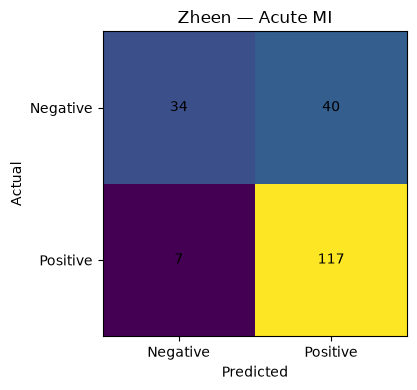

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


def plot_binary_confusion_matrix(
    y_true,
    y_prob,
    title,
    threshold=0.5,
):
    y_pred = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.xticks(
        [0, 1],
        ["Negative", "Positive"]
    )

    plt.yticks(
        [0, 1],
        ["Negative", "Positive"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()


zheen_predictions = (
    all_predictions["zheen"]["acute_mi"]
)

plot_binary_confusion_matrix(
    zheen_predictions["true"],
    zheen_predictions["pred"],
    "Zheen — Acute MI",
    threshold=thresholds["acute_mi"],
)

In [33]:
binary_results = metrics_df[
    ~metrics_df["target"].isin(
        MULTICLASS_TARGETS
    )
].copy()

binary_results = binary_results.sort_values(
    "auroc",
    ascending=False
)

display(
    binary_results[
        [
            "dataset",
            "target",
            "auroc",
            "auprc",
            "f1",
        ]
    ].round(4)
)

,dataset,target,auroc,auprc,f1
3,mi_complications,post_mi_svt,0.9961,0.5000,0.0741
4,mi_complications,post_mi_vt,0.9552,0.2503,0.2222
7,mi_complications,post_mi_myocardial_rupture,0.9228,0.3275,0.3125
0,zheen,acute_mi,0.8922,0.9425,0.8327
2,mi_complications,post_mi_af,0.8328,0.4064,0.3467
5,mi_complications,post_mi_vf,0.8059,0.2010,0.3077
6,mi_complications,post_mi_av_block,0.7486,0.1877,0.1471
10,mi_complications,post_mi_recurrent_mi,0.7170,0.1846,0.2338
11,mi_complications,post_mi_angina,0.7017,0.2015,0.1698
8,mi_complications,post_mi_dressler,0.6972,0.1004,0.1308


In [34]:
metrics_path = (
    RESULTS_DIR
    / "biomarker_test_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

print(
    "Saved:",
    metrics_path
)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\biomarkers\biomarker_test_metrics.csv


In [35]:
prediction_rows = []

for dataset_name, predictions in all_predictions.items():

    for target, values in predictions.items():

        for true, pred in zip(
            values["true"],
            values["pred"]
        ):

            prediction_rows.append({
                "dataset": dataset_name,
                "target": target,
                "true": true,
                "prediction": pred,
            })

predictions_df = pd.DataFrame(
    prediction_rows
)

prediction_path = (
    RESULTS_DIR
    / "biomarker_test_predictions.csv"
)

predictions_df.to_csv(
    prediction_path,
    index=False
)

print(
    "Saved:",
    prediction_path
)

Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\biomarkers\biomarker_test_predictions.csv


In [36]:
def prediction_frame(prediction_map):
    rows = []

    for dataset_name, predictions in prediction_map.items():
        for target, values in predictions.items():
            for true, pred in zip(values["true"], values["pred"]):
                rows.append({
                    "dataset": dataset_name,
                    "target": target,
                    "true": true,
                    "prediction": pred,
                })

    return pd.DataFrame(rows)

validation_predictions_df = prediction_frame(
    validation_predictions
)
validation_prediction_path = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "biomarkers"
    / "biomarker_val_predictions.csv"
)
validation_prediction_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)
validation_predictions_df.to_csv(
    validation_prediction_path,
    index=False,
)

predictions_df = prediction_frame(all_predictions)
prediction_path = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "biomarkers"
    / "biomarker_test_predictions.csv"
)
prediction_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)
predictions_df.to_csv(prediction_path, index=False)

print("Saved validation predictions:", validation_prediction_path)
print("Saved test predictions:", prediction_path)

Saved validation predictions: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\biomarkers\biomarker_val_predictions.csv
Saved test predictions: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\biomarkers\biomarker_test_predictions.csv
